### ROLL NO - DA24C011

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
from sklearn.metrics import accuracy_score, precision_score

In [2]:
#pip install ucimlrepo

In [33]:
from ucimlrepo import fetch_ucirepo 
  
nursery = fetch_ucirepo(id=76) 
  
X = nursery.data.features 
y = nursery.data.targets
#X.info()

In [34]:
#X.head()

In [32]:
y['class'].unique()

In [31]:
y['class']=y['class'].replace('very_recom','recommend')
y['class']=y['class'].replace('spec_prior','recommend')


In [4]:
#required funtions

def data_split(X,y): #performs train test split on the data 
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)
    return X_train, X_test, y_train,y_test

def gridSearch_CV(model,param_grid,X_train, X_test, y_train,y_test): 
    
    #grid search with 80-20 train-eval split and specified model and parameters
    grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)
    grid_search.fit(X_train, y_train)
    
    #calculating accuracy and precision of the best model on test data
    y_pred = grid_search.best_estimator_.predict(X_test)
    accuracy=accuracy_score(y_test, y_pred)*100
    precision = precision_score(y_test, y_pred, average='weighted')*100
    return(accuracy,precision)

def task_function(X,y,model,param_grid):
    accuracies = []
    precisions = []
    #repeating the task 5 times on samples
    for _ in range(5):
        X_train, X_test, y_train, y_test = data_split(X,y)
        acc,prec= gridSearch_CV(model,param_grid,X_train, X_test, y_train, y_test)
        accuracies.append(acc)
        precisions.append(prec)
    
    #mean variance of the scores of the samples
    mean_acc = np.mean(accuracies)
    variance_acc = np.var(accuracies)
    mean_prec = np.mean(precisions)
    variance_prec = np.var(precisions)
    print(f"Mean of accuracies: {mean_acc:.4f}, Variance of accuracies: {variance_acc}, Mean of precisions: {mean_prec:.4f}, Variance of precisions: {variance_prec}")
    return([mean_acc,variance_acc,mean_prec,variance_prec])

### Decision Tree (categorical features)

In [5]:
#getting map list
cols = X.columns
map_list = []
for col in cols:
    map_list.append('map_'+col)

In [6]:
#label encoding
X_new = pd.DataFrame()
for i in range(0,len(cols),1):
    label_encoder = LabelEncoder()
    X_new[map_list[i]] = label_encoder.fit_transform(X[cols[i]])

y_new = pd.DataFrame()
label_encoder = LabelEncoder()
y_new['enc_class'] = label_encoder.fit_transform(y['class'])

In [7]:
#modelling decision tree classifier
model_dtc = DecisionTreeClassifier()
param_grid_dtc = {'max_depth':[5,7,9,10,15],
                 'min_samples_leaf':[10,15,20],
                 'min_samples_split':[20,30,40]}
dtc_ans=task_function(X_new,y_new,model_dtc,param_grid_dtc)
    


Mean of accuracies: 96.8416, Variance of accuracies: 0.0008996765398229655, Mean of precisions: 96.8494, Variance of precisions: 0.0005610238434120107


### Decision Tree (One hot encoding)

In [8]:
#one hot encoding
encoder = OneHotEncoder(sparse=False)
encoded_data =  encoder.fit_transform(X)
encoded_classes = encoder.fit_transform(y)

In [9]:
#modelling decision tree classifier on one hot encoded data
model_dt_ohe = DecisionTreeClassifier()
param_grid_dt_ohe = {'max_depth':[5,7,9,10,15],
                 'min_samples_leaf':[10,15,20],
                 'min_samples_split':[20,30,40]}
ohe_ans=task_function(encoded_data,encoded_classes,model_dt_ohe,param_grid_dt_ohe)

Mean of accuracies: 96.0391, Variance of accuracies: 0.13997908516655372, Mean of precisions: 96.7943, Variance of precisions: 0.0697852393802166


### Logistic regression with L1 regularisation

In [10]:
#modelling logisitic regression with l1 penalty on one hot encoded data
model_lr = LogisticRegression(penalty='l1', solver='saga', max_iter=3000)
param_lr = {'C':[0.01,0.1,1,10,100]}
lr_ans=task_function(encoded_data,y,model_lr,param_lr)

C:\Users\pooja\anaconda3\lib\site-packages\sklearn\utils\validation.py:993: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\pooja\anaconda3\lib\site-packages\sklearn\utils\validation.py:993: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\pooja\anaconda3\lib\site-packages\sklearn\utils\validation.py:993: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\pooja\anaconda3\lib\site-packages\sklearn\utils\validation.py:993: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), 

Mean of accuracies: 91.5689, Variance of accuracies: 0.16919211163609807, Mean of precisions: 91.5791, Variance of precisions: 0.1674076208301371


### KNN

In [28]:
#modelling KNN on one hot encoded data
model_knn = KNeighborsClassifier()
param_grid_knn = {'n_neighbors':[3, 5, 7, 9], 
                  'weights':['uniform', 'distance']}
knn_ans = task_function(encoded_data,y,model_knn,param_grid_knn)

C:\Users\pooja\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:198: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\Users\pooja\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:198: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\Users\pooja\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:198: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\Users\pooja\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:198: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_sam

Mean of accuracies: 95.4167, Variance of accuracies: 0.1347927145252247, Mean of precisions: 95.5662, Variance of precisions: 0.10239000091923008


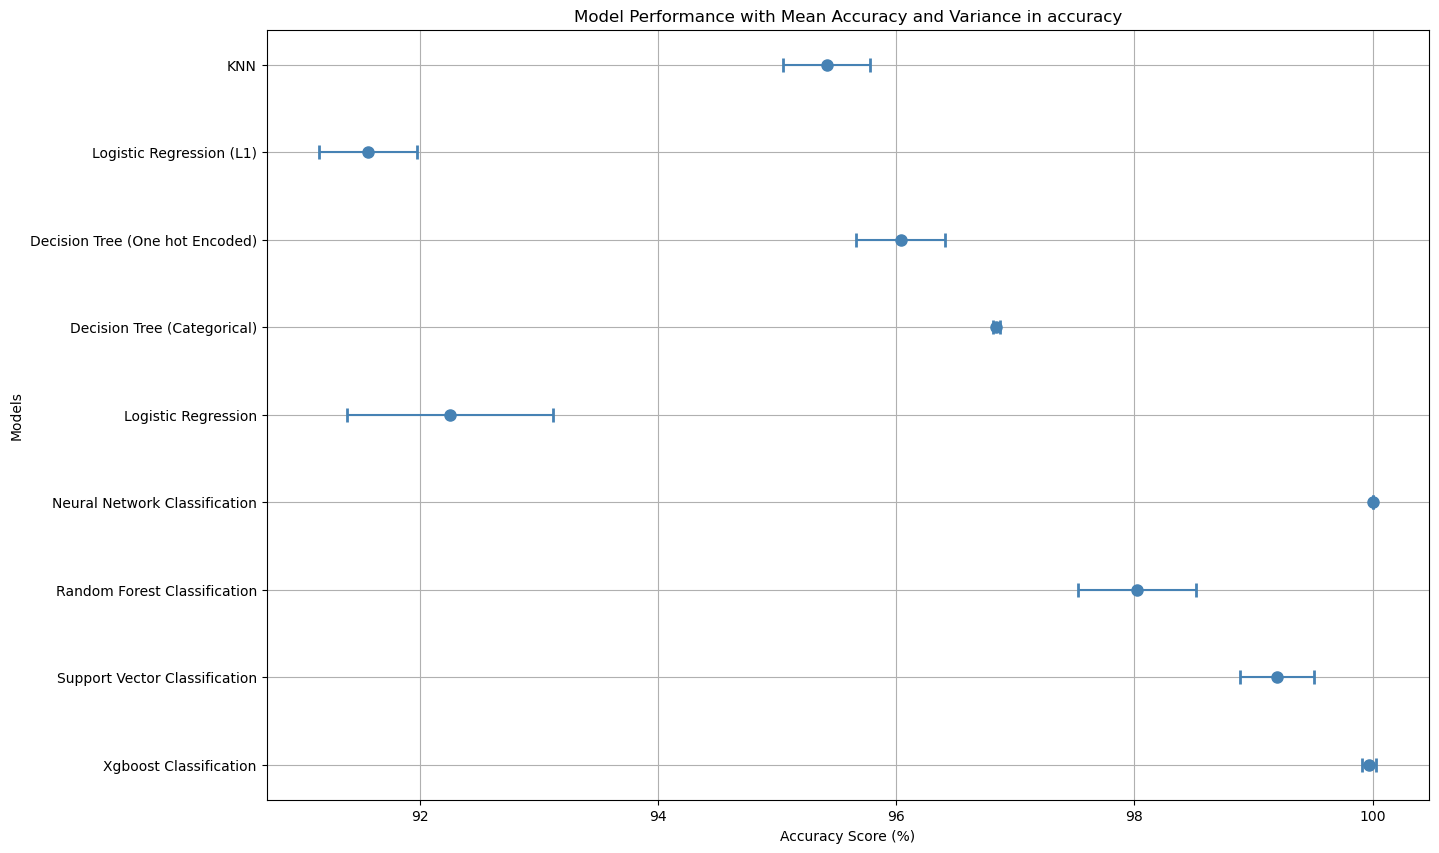

In [29]:
#box whisker plot of accuracy
models=['Xgboost Classification', 'Support Vector Classification', 'Random Forest Classification', 
             'Neural Network Classification', 'Logistic Regression', 'Decision Tree (Categorical)', 
             'Decision Tree (One hot Encoded)', 'Logistic Regression (L1)', 'KNN']
means = [99.969, 99.198, 98.025, 100, 92.253, dtc_ans[0], ohe_ans[0], lr_ans[0], knn_ans[0]]
variances = [  0.0038, 0.095, 0.244,0, 0.746, dtc_ans[1], ohe_ans[1], lr_ans[1], knn_ans[1]]
std_dev = np.sqrt(variances)
plt.figure(figsize=(15, 10))
plt.errorbar(means, models, xerr=std_dev, fmt='o', capsize=5, capthick=2,markersize=8, color='steelblue')
plt.xlabel('Accuracy Score (%)')
plt.ylabel('Models')
plt.title('Model Performance with Mean Accuracy and Variance in accuracy')
plt.grid(True) 
plt.show()

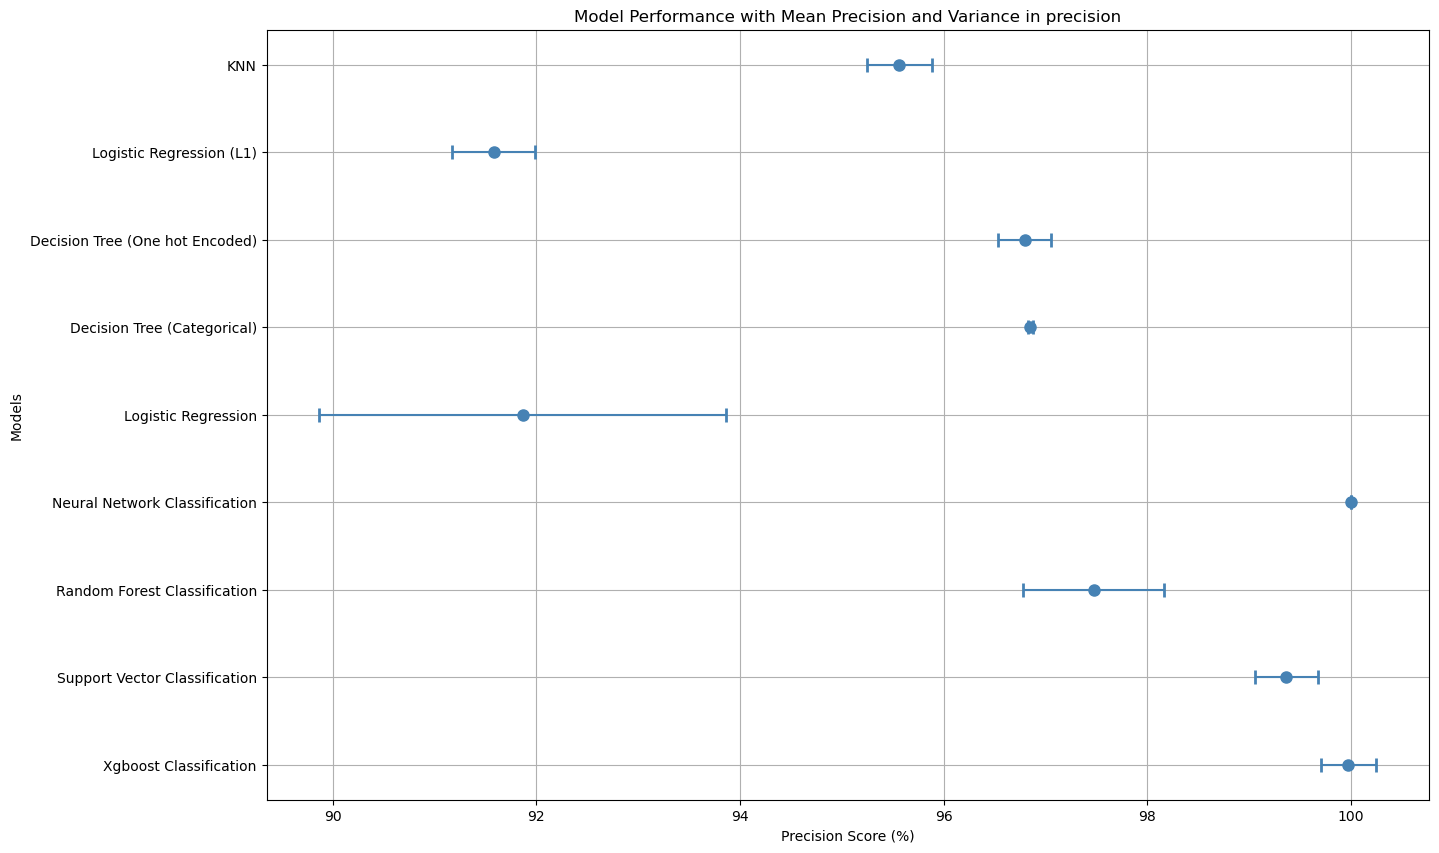

In [30]:
#box whisker plot of precision
models=['Xgboost Classification', 'Support Vector Classification', 'Random Forest Classification', 
             'Neural Network Classification', 'Logistic Regression', 'Decision Tree (Categorical)', 
             'Decision Tree (One hot Encoded)', 'Logistic Regression (L1)', 'KNN']
means = [99.976, 99.367, 97.473, 100, 91.868, dtc_ans[2], ohe_ans[2], lr_ans[2], knn_ans[2]]
variances = [  0.074, 0.095, 0.475,0, 3.997, dtc_ans[3], ohe_ans[3], lr_ans[3], knn_ans[3]]
std_dev = np.sqrt(variances)
plt.figure(figsize=(15, 10))
plt.errorbar(means, models, xerr=std_dev, fmt='o', capsize=5, capthick=2,markersize=8, color='steelblue')
plt.xlabel('Precision Score (%)')
plt.ylabel('Models')
plt.title('Model Performance with Mean Precision and Variance in precision')
plt.grid(True) 
plt.show()

### Interpretations (in terms of accuracies and precisions):
1. Neural network classifcation works best for the data (100% accuracy and no variance).
2. Out of all the self run models, decision trees have the highest accuracy and precision. However, since decision tree (one hot encoded) has variance greater than that of the decision tree categorical model, the latter is a better model for our data.
3. Logistic regression (both, with l1 penalty and the model given on the site) have low scores as compared to the rest of the models. Hence, logistic regression might not be a good fit for the data.

### Task 2

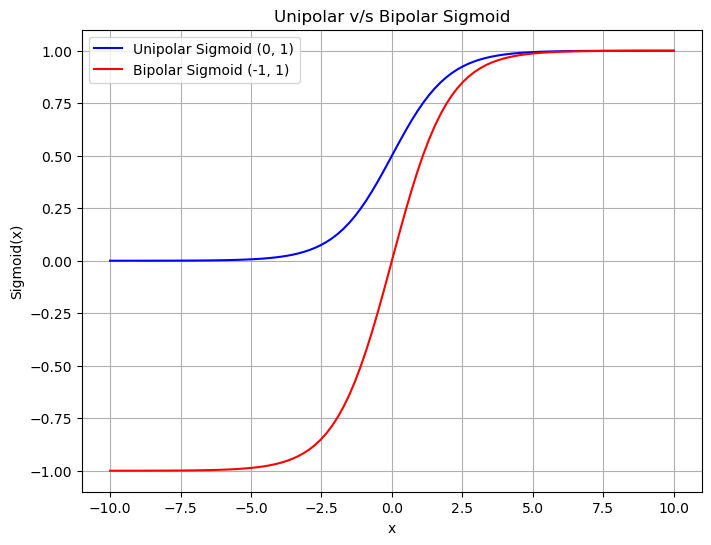

In [24]:
#sigmoid functions
def sigmoid(x):
    return (1/(1 + np.exp(-x)))

def bipolar_sigmoid(x):
    return (2*sigmoid(x)-1)

#generating data
x = np.linspace(-10, 10, 100)
y_uni = sigmoid(x)
y_bi = bipolar_sigmoid(x)

#plotting functions
plt.figure(figsize=(8, 6))
plt.plot(x, y_uni, label='Unipolar Sigmoid (0, 1)', color='blue')
plt.plot(x, y_bi, label='Bipolar Sigmoid (-1, 1)', color='red')
plt.title('Unipolar v/s Bipolar Sigmoid')
plt.xlabel('x')
plt.ylabel('Sigmoid(x)')
plt.grid(True)
plt.legend()
plt.show()

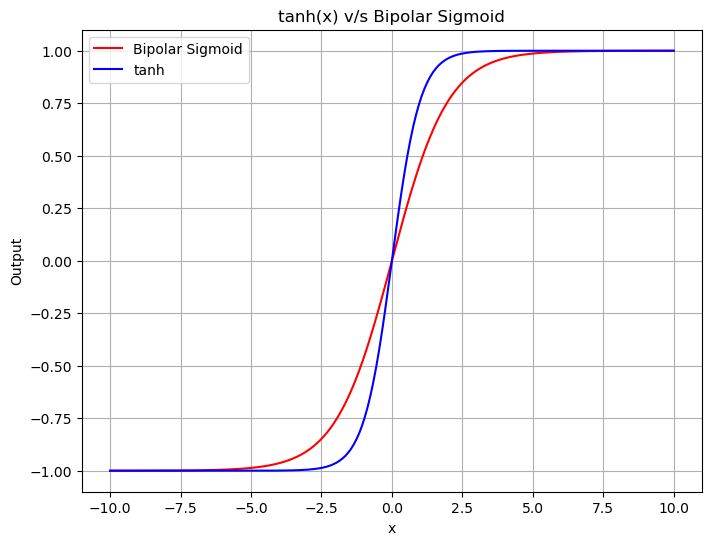

In [21]:
# tanh function
def tanh(x):
    return (np.tanh(x))

#generating data
x = np.linspace(-10, 10, 200)
y_bi = bipolar_sigmoid(x)
y_tanh = tanh(x)

#plotting functions
plt.figure(figsize=(8, 6))
plt.plot(x, y_bi, label='Bipolar Sigmoid', color='red')
plt.plot(x, y_tanh, label='tanh', color='blue')
plt.title('tanh(x) v/s Bipolar Sigmoid')
plt.xlabel('x')
plt.ylabel('Output')
plt.legend()
plt.grid(True)
plt.show()


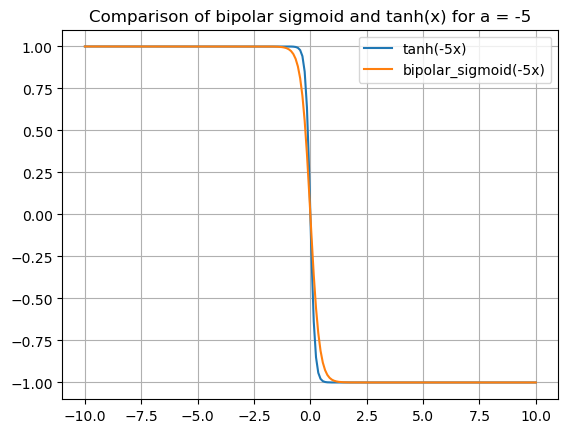

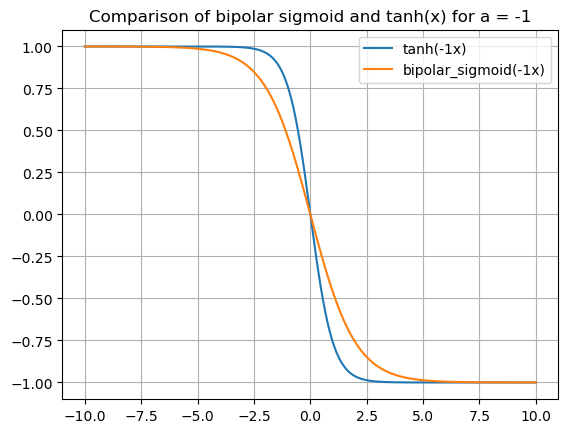

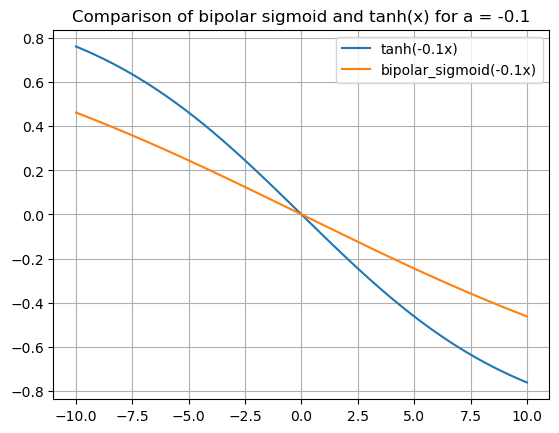

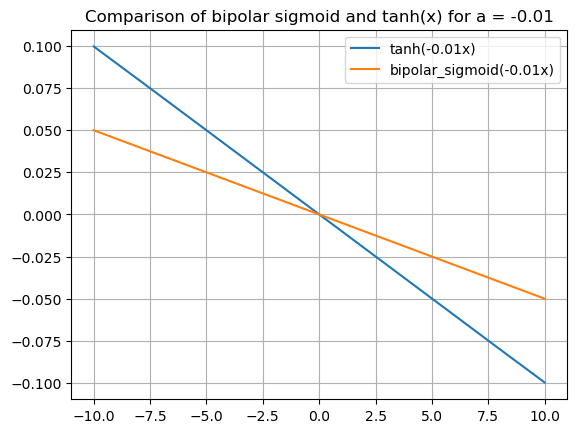

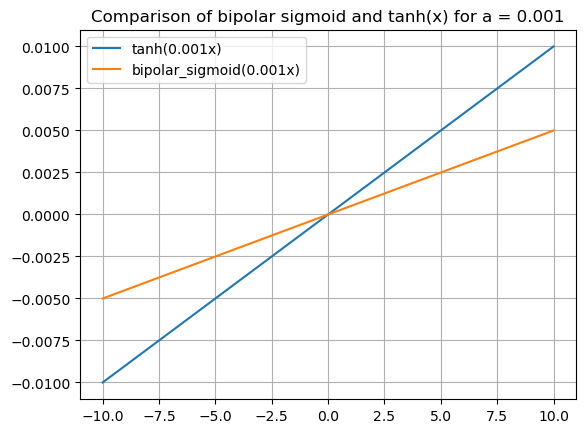

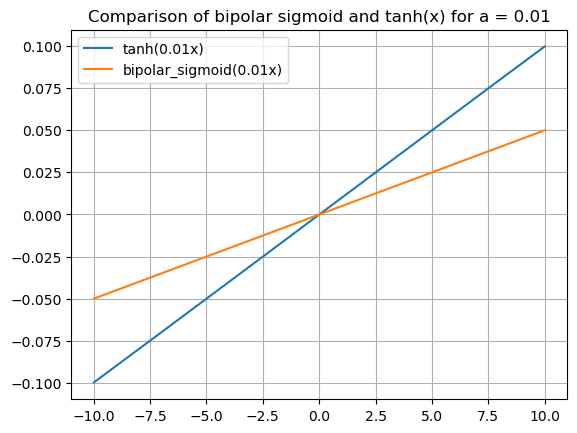

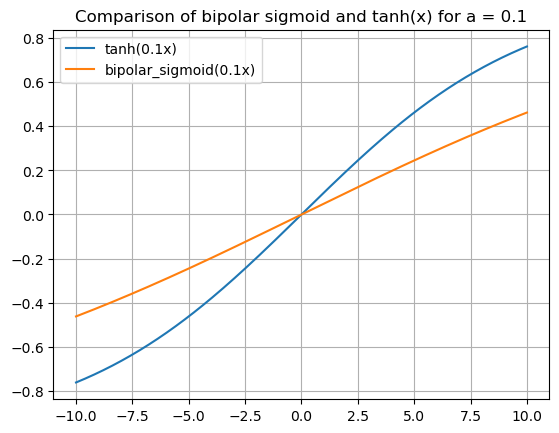

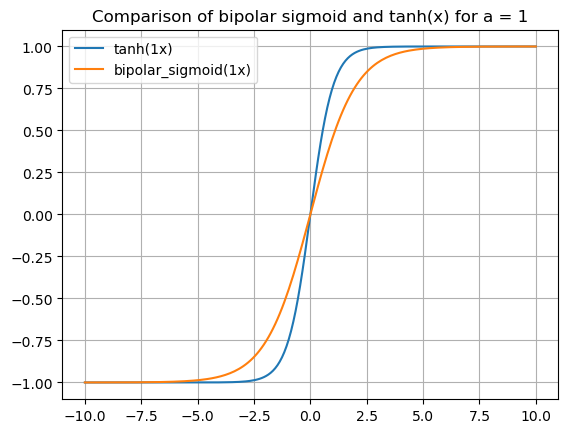

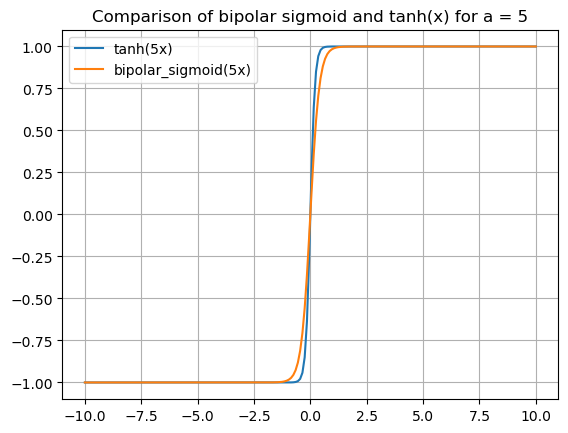

In [26]:
a_values = [-5, -1, -0.1, -0.01, 0.001, 0.01, 0.1, 1, 5]
x = np.linspace(-10, 10, 200)

for a in a_values:
    y_tanh_a = np.tanh(a*x)
    y_bipolar_sigmoid_a = bipolar_sigmoid(a*x)
    
    plt.plot(x, y_tanh_a, label=f'tanh({a}x)')
    plt.plot(x, y_bipolar_sigmoid_a, label=f'bipolar_sigmoid({a}x)')
    plt.legend()
    plt.grid(True)
    plt.title(f'Comparison of bipolar sigmoid and tanh(x) for a = {a}')
    plt.show()

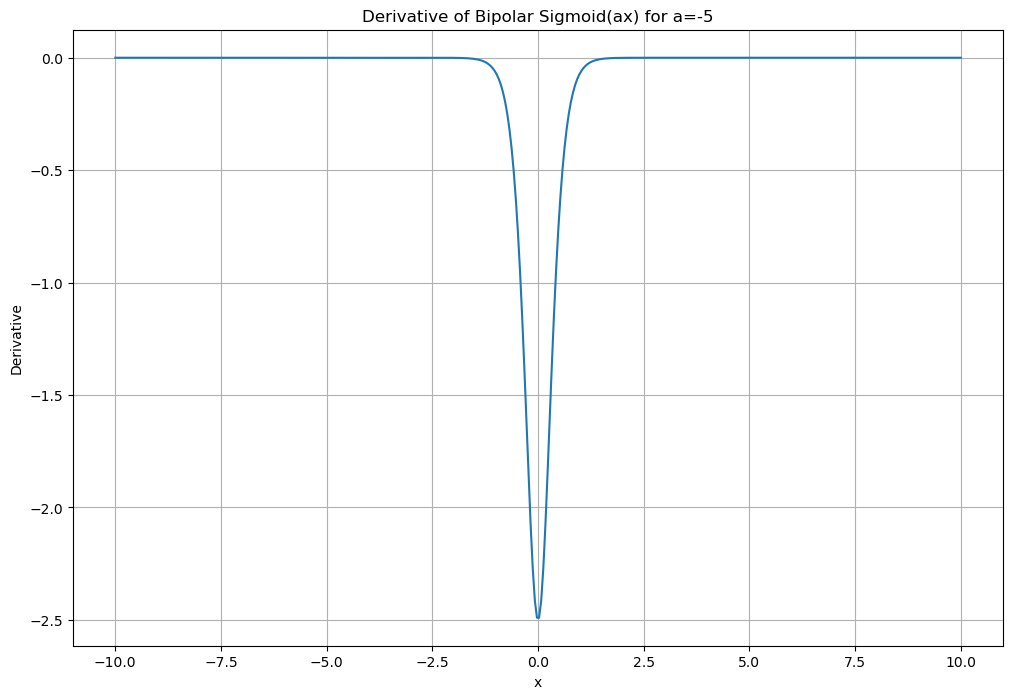

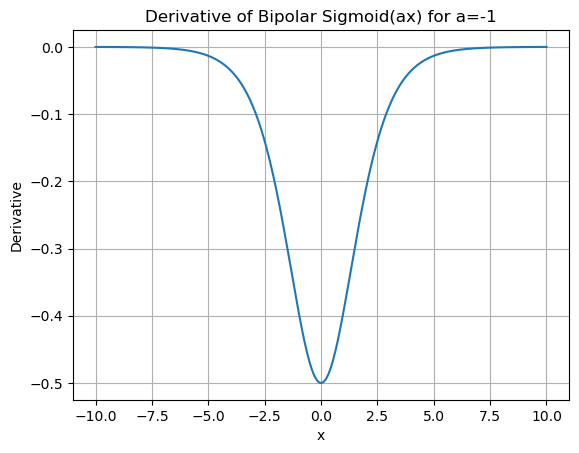

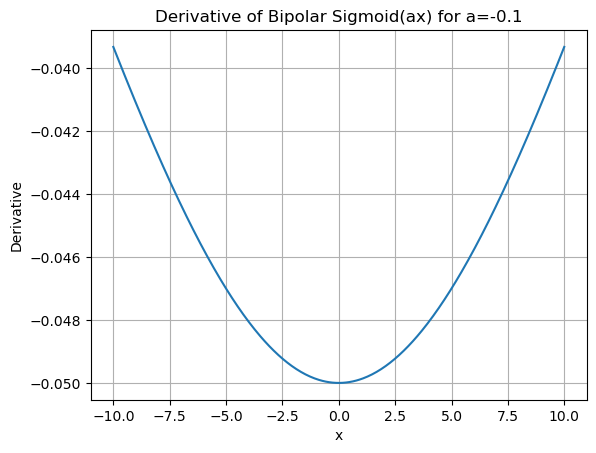

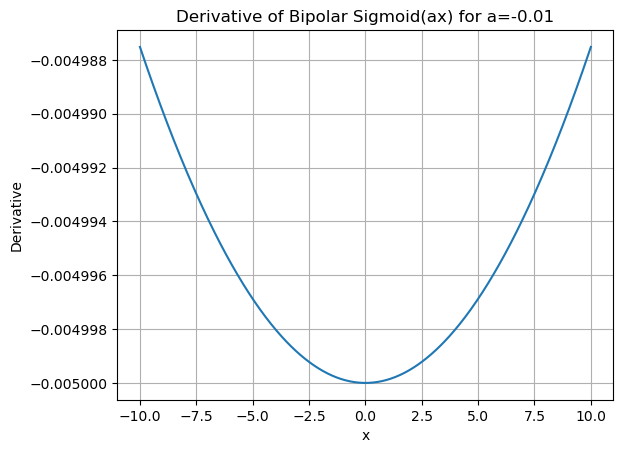

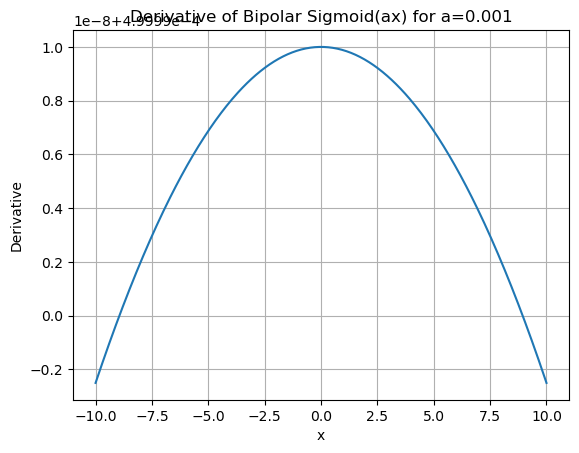

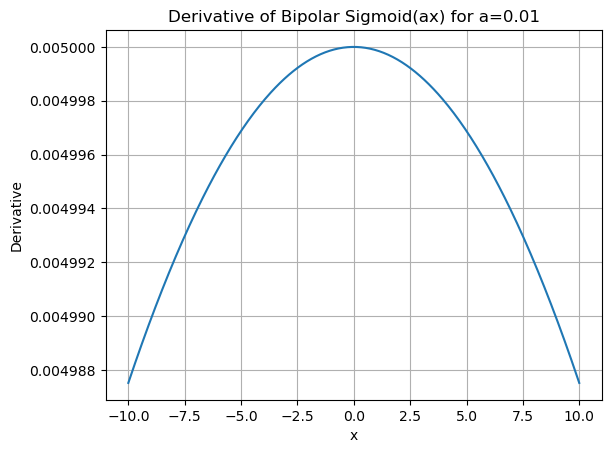

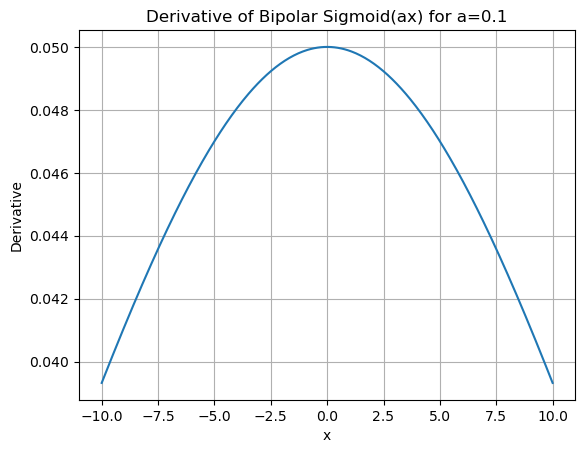

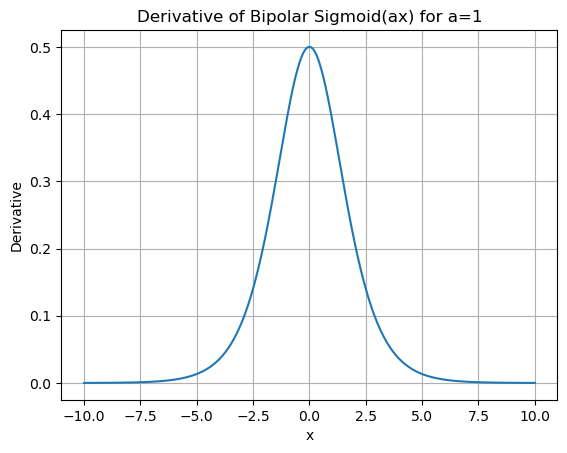

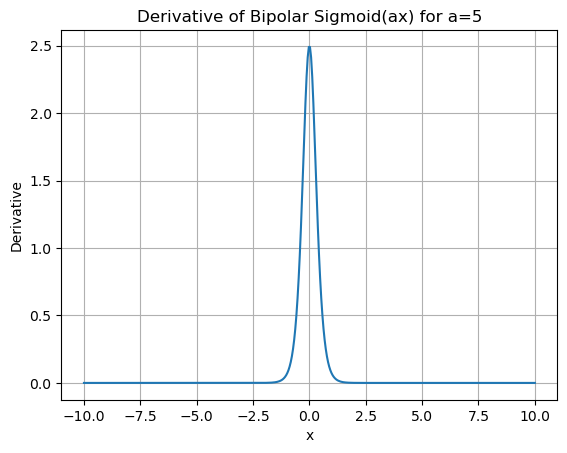

In [27]:
def bipolar_sigmoid_derivative(x, a):
    sig = sigmoid(a*x)
    return (2 *a*sig*(1 - sig))


a_values = [-5, -1, -0.1, -0.01, 0.001, 0.01, 0.1, 1, 5]
x = np.linspace(-10, 10, 400)

plt.figure(figsize=(12, 8))
for a in a_values:
    y_derivative = bipolar_sigmoid_derivative(x, a)
    plt.plot(x, y_derivative)

    plt.title(f'Derivative of Bipolar Sigmoid(ax) for a={a}')
    plt.xlabel('x')
    plt.ylabel('Derivative')
    plt.grid(True)
    plt.show()